In [1]:
import tensorflow as tf

In [2]:
# Load the MNIST dataset
mnist = tf.keras.datasets.mnist

In [3]:
# Load the training and test split of the MNIST dataset
(training_images, training_labels), (test_images, test_labels) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step



IMAGE PIXEL ARRAY:
 [[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 1

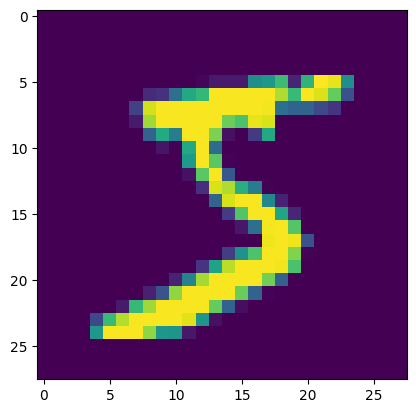

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# You can put between 0 to 59999 here
index = 0

# Set number of characters per row when printing
np.set_printoptions(linewidth=320)

# Print the label and image
print(f'\nIMAGE PIXEL ARRAY:\n {training_images[index]}')

# Visualize the image
print(f'LABEL: {training_labels[index]}')
plt.imshow(training_images[index])
plt.show()

In [5]:
# Normalize the pixel values of the train and test images
training_images  = training_images / 255.0
test_images = test_images / 255.0


In [9]:
# Build the classification model
model = tf.keras.models.Sequential([tf.keras.layers.Flatten(),
                                    tf.keras.layers.Dense(64, activation=tf.nn.relu),
                                    tf.keras.layers.Dense(10, activation=tf.nn.softmax)])

In [10]:
model.compile(optimizer = tf.optimizers.Adam(),
              loss = 'sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(training_images, training_labels, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9130 - loss: 0.3063
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9572 - loss: 0.1476
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9682 - loss: 0.1082
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9739 - loss: 0.0863
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9790 - loss: 0.0705


In [11]:
# Evaluate the model on unseen data
model.evaluate(test_images, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9725 - loss: 0.0938


[0.0937749519944191, 0.9725000262260437]

In [12]:
classifications = model.predict(test_images)

print(classifications[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
[3.6932329e-06 3.7256866e-06 9.9988556e-01 2.8258688e-05 2.8727460e-13 7.4416726e-05 2.3751545e-06 7.4633527e-10 2.0747054e-06 1.8131684e-11]


In [16]:
print(test_labels[1])

2


In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Get predicted labels from classifications
predicted_labels = np.argmax(classifications, axis=1)

# Find indices where prediction is incorrect
misclassified_indices = np.where(predicted_labels != test_labels)[0]

print(f"Number of misclassified images: {len(misclassified_indices)}")


Number of misclassified images: 275


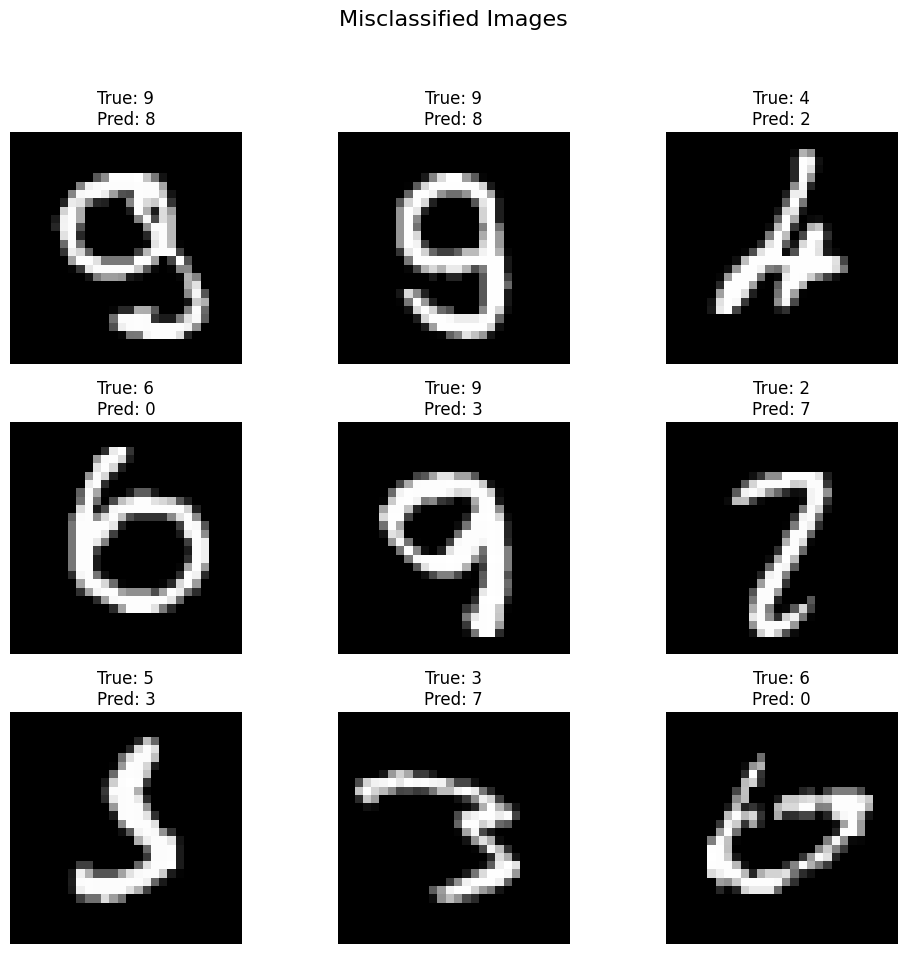

In [21]:
# Visualize a few misclassified images
plt.figure(figsize=(10, 10))
for i, bad_index in enumerate(misclassified_indices[:9]): # Display up to 9 misclassified images
    plt.subplot(3, 3, i + 1)
    plt.imshow(test_images[bad_index], cmap='gray')
    plt.title(f"True: {test_labels[bad_index]}\nPred: {predicted_labels[bad_index]}")
    plt.axis('off')
plt.suptitle('Misclassified Images', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [19]:
# Install Gradio
!pip install gradio -q

import gradio as gr
import numpy as np
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

# MNIST class names
class_names = [
    "Zero", "One", "Two", "Three", "Four",
    "Five", "Six", "Seven", "Eight", "Nine"
]

def predict_image(uploaded_image):
    """
    This function takes an uploaded image,
    preprocesses it like MNIST,
    and predicts its class using the trained model.
    """

    # Convert uploaded image to grayscale
    img = uploaded_image.convert("L")

    # Resize image to 28x28 because MNIST images are 28x28
    img = img.resize((28, 28))

    # Invert image colors to match MNIST style
    img = ImageOps.invert(img)

    # Convert image to numpy array
    img_array = np.array(img)

    # Normalize pixel values from 0-255 to 0-1
    img_array = img_array / 255.0

    # Add batch dimension: (28, 28) becomes (1, 28, 28)
    img_input = np.expand_dims(img_array, axis=0)

    # Predict using trained model
    prediction = model.predict(img_input)

    # Get predicted class index
    predicted_index = np.argmax(prediction[0])

    # Get confidence percentage
    confidence = np.max(prediction[0]) * 100

    # Create result text
    result = f"Prediction: {class_names[predicted_index]}\nConfidence: {confidence:.2f}%"

    # Return all class probabilities also
    probabilities = {
        class_names[i]: float(prediction[0][i])
        for i in range(len(class_names))
    }

    return result, probabilities


# Create Gradio interface
demo = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type="pil", label="Upload Image"),
    outputs=[
        gr.Textbox(label="Prediction Result"),
        gr.Label(num_top_classes=10, label="Class Probabilities")
    ],
    title="MNIST Image Classifier",
    description="The model will predict the MNIST class."
)

# Launch app
demo.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d7ed91e20631056eb9.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
